<a href="https://colab.research.google.com/github/syarifokie/hellogitworld/blob/master/MotorFaultDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

df = pd.read_excel("Motor_Fault_Detection_Dataset.xlsx")
df.head()

,Vibration_Amplitude,RMS_Vibration,Vibration_Frequency,Surface_Temperature,Exhaust_Temperature,Acoustic_dB,Acoustic_Frequency,Intake_Pressure,Exhaust_Pressure,Frequency_Band_Energy,Amplitude_Mean,Engine_Condition
0,3.807947,1.899522,1465.396656,106.577348,319.564816,110.834195,NaN,91.279833,104.544934,0.889443,0.294582,0
1,9.512072,1.697915,385.333751,85.115094,237.927110,89.671023,4417.399188,114.855139,84.358093,0.916455,0.268216,0
2,7.346740,0.921962,706.346595,145.739823,250.543690,71.727937,2369.581389,97.479227,108.393914,0.440535,0.182008,0
3,6.026719,3.055970,1333.295661,56.277414,272.268451,104.198507,1516.975785,98.518121,105.296723,0.308468,0.251674,2
4,1.644585,2.409290,974.536902,100.542770,281.461334,85.120688,1662.348214,96.787358,107.565599,0.272495,0.188897,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print()
df.info()

Shape: (10000, 12)

Columns: ['Vibration_Amplitude', 'RMS_Vibration', 'Vibration_Frequency', 'Surface_Temperature', 'Exhaust_Temperature', 'Acoustic_dB', 'Acoustic_Frequency', 'Intake_Pressure', 'Exhaust_Pressure', 'Frequency_Band_Energy', 'Amplitude_Mean', 'Engine_Condition']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Vibration_Amplitude    9894 non-null   float64
 1   RMS_Vibration          9931 non-null   float64
 2   Vibration_Frequency    9860 non-null   float64
 3   Surface_Temperature    9824 non-null   float64
 4   Exhaust_Temperature    9908 non-null   float64
 5   Acoustic_dB            9840 non-null   float64
 6   Acoustic_Frequency     9857 non-null   float64
 7   Intake_Pressure        9839 non-null   float64
 8   Exhaust_Pressure       9853 non-null   float64
 9   Frequency_Band_Energy  9869 non-null

In [4]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Vibration_Amplitude,9894.0,4.994,2.846,0.100,2.542,4.979,7.422,9.997
RMS_Vibration,9931.0,2.548,1.433,0.051,1.306,2.554,3.795,5.000
Vibration_Frequency,9860.0,1010.200,568.124,20.095,522.421,1014.266,1494.633,1999.804
Surface_Temperature,9824.0,89.864,34.664,30.001,59.658,89.981,119.654,149.975
Exhaust_Temperature,9908.0,398.970,115.635,200.007,298.161,397.993,500.262,599.989
Acoustic_dB,9840.0,90.177,17.314,60.001,75.409,90.357,105.202,119.996
Acoustic_Frequency,9857.0,2559.188,1408.877,101.324,1344.156,2568.628,3788.394,4998.480
Intake_Pressure,9839.0,104.962,8.581,90.004,97.562,104.949,112.424,119.996
Exhaust_Pressure,9853.0,95.040,8.740,80.004,87.327,95.139,102.768,110.000
Frequency_Band_Energy,9869.0,0.545,0.259,0.100,0.320,0.546,0.768,1.000


In [5]:
counts = df["Engine_Condition"].value_counts().sort_index()
percent = (df["Engine_Condition"].value_counts(normalize=True).sort_index() * 100).round(2)
print(pd.DataFrame({"Count": counts, "Percent (%)": percent}))

                  Count  Percent (%)
Engine_Condition                    
0                  5963        59.63
1                  3037        30.37
2                  1000        10.00


In [6]:
missing = df.isnull().sum()
print(missing)
print("\nTotal missing cells:", missing.sum())
print("Rows with at least one missing value:", df.isnull().any(axis=1).sum())
print("Duplicate rows:", df.duplicated().sum())

Vibration_Amplitude      106
RMS_Vibration             69
Vibration_Frequency      140
Surface_Temperature      176
Exhaust_Temperature       92
Acoustic_dB              160
Acoustic_Frequency       143
Intake_Pressure          161
Exhaust_Pressure         147
Frequency_Band_Energy    131
Amplitude_Mean            98
Engine_Condition           0
dtype: int64

Total missing cells: 1423
Rows with at least one missing value: 1336
Duplicate rows: 0


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Engine_Condition")
y = df["Engine_Condition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nTrain class %:\n", (y_train.value_counts(normalize=True).sort_index()*100).round(2))
print("\nTest class %:\n", (y_test.value_counts(normalize=True).sort_index()*100).round(2))

Train: (8000, 11) | Test: (2000, 11)

Train class %:
 Engine_Condition
0    59.62
1    30.38
2    10.00
Name: proportion, dtype: float64

Test class %:
 Engine_Condition
0    59.65
1    30.35
2    10.00
Name: proportion, dtype: float64


In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# fit on TRAIN only, then transform both
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# keep column names for later plots and feature importance
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

In [9]:
print("Missing after imputation (train):", X_train_scaled.isnull().sum().sum())
print("Missing after imputation (test): ", X_test_scaled.isnull().sum().sum())
print("\nTrain mean (should be ~0):\n", X_train_scaled.mean().round(3).head(3))
print("\nTrain std (should be ~1):\n", X_train_scaled.std().round(3).head(3))

Missing after imputation (train): 0
Missing after imputation (test):  0

Train mean (should be ~0):
 Vibration_Amplitude    0.0
RMS_Vibration          0.0
Vibration_Frequency    0.0
dtype: float64

Train std (should be ~1):
 Vibration_Amplitude    1.0
RMS_Vibration          1.0
Vibration_Frequency    1.0
dtype: float64


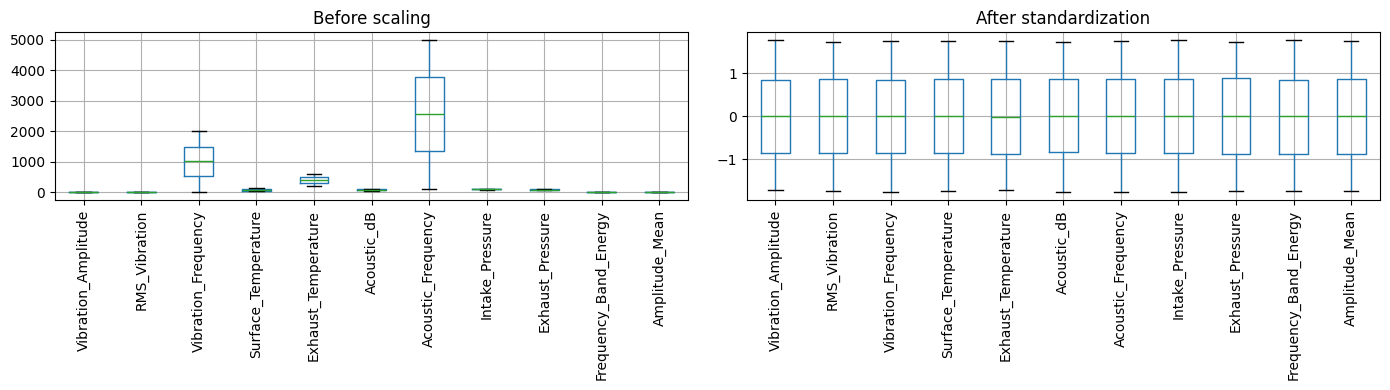

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
X_train_imp_df = pd.DataFrame(X_train_imp, columns=X.columns)
X_train_imp_df.boxplot(ax=ax[0], rot=90); ax[0].set_title("Before scaling")
X_train_scaled.boxplot(ax=ax[1], rot=90); ax[1].set_title("After standardization")
plt.tight_layout(); plt.show()

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

models = {
    "Dummy (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(kernel="rbf", class_weight="balanced", random_state=42),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

def make_pipe(clf):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", clf),
    ])

In [12]:
import time
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Use the RAW split from Step 2 (X_train, X_test, y_train, y_test).
# The pipeline does the imputing and scaling itself.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows, predictions, fitted = [], {}, {}

for name, clf in models.items():
    pipe = make_pipe(clf)
    t0 = time.time()
    pipe.fit(X_train, y_train)                    # .fit
    train_time = time.time() - t0
    y_pred = pipe.predict(X_test)                 # .predict
    predictions[name], fitted[name] = y_pred, pipe

    cv = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="f1_macro", n_jobs=-1)

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
        "Critical recall": recall_score(y_test, y_pred, labels=[2], average="macro"),
        "CV F1 mean": cv.mean(),
        "CV F1 std": cv.std(),
        "Train time (s)": train_time,
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Critical recall,CV F1 mean,CV F1 std,Train time (s)
Model,,,,,,,,
Dummy (most frequent),0.596,0.199,0.333,0.249,0.000,0.249,0.000,0.029
Logistic Regression,0.323,0.356,0.360,0.304,0.440,0.290,0.005,0.046
Decision Tree,0.236,0.339,0.341,0.221,0.455,0.233,0.060,0.208
Random Forest,0.592,0.269,0.332,0.252,0.000,0.256,0.004,7.261
SVM (RBF),0.335,0.335,0.338,0.302,0.335,0.308,0.014,5.453
k-NN (k=5),0.544,0.385,0.345,0.330,0.035,0.312,0.004,0.025


In [13]:
target_names = ["Normal (0)", "Minor (1)", "Critical (2)"]
for name, y_pred in predictions.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


=== Dummy (most frequent) ===
              precision    recall  f1-score   support

  Normal (0)       0.60      1.00      0.75      1193
   Minor (1)       0.00      0.00      0.00       607
Critical (2)       0.00      0.00      0.00       200

    accuracy                           0.60      2000
   macro avg       0.20      0.33      0.25      2000
weighted avg       0.36      0.60      0.45      2000

Confusion matrix:
 [[1193    0    0]
 [ 607    0    0]
 [ 200    0    0]]

=== Logistic Regression ===
              precision    recall  f1-score   support

  Normal (0)       0.63      0.29      0.40      1193
   Minor (1)       0.33      0.35      0.34       607
Critical (2)       0.11      0.44      0.17       200

    accuracy                           0.32      2000
   macro avg       0.36      0.36      0.30      2000
weighted avg       0.49      0.32      0.36      2000

Confusion matrix:
 [[346 355 492]
 [163 212 232]
 [ 44  68  88]]

=== Decision Tree ===
              pr

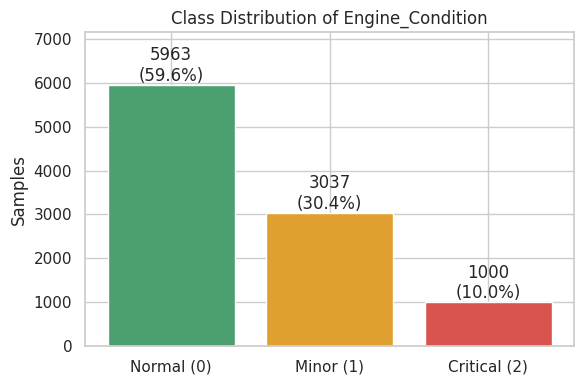

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

labels = ["Normal (0)", "Minor (1)", "Critical (2)"]
colors = ["#4C9F70", "#E0A030", "#D9534F"]

fig, ax = plt.subplots(figsize=(6, 4))
c = df["Engine_Condition"].value_counts().sort_index()
bars = ax.bar(labels, c.values, color=colors)
for b, v in zip(bars, c.values):
    ax.text(b.get_x() + b.get_width()/2, v + 80, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
ax.set_ylabel("Samples"); ax.set_ylim(0, c.max()*1.2)
ax.set_title("Class Distribution of Engine_Condition")
plt.tight_layout(); plt.show()

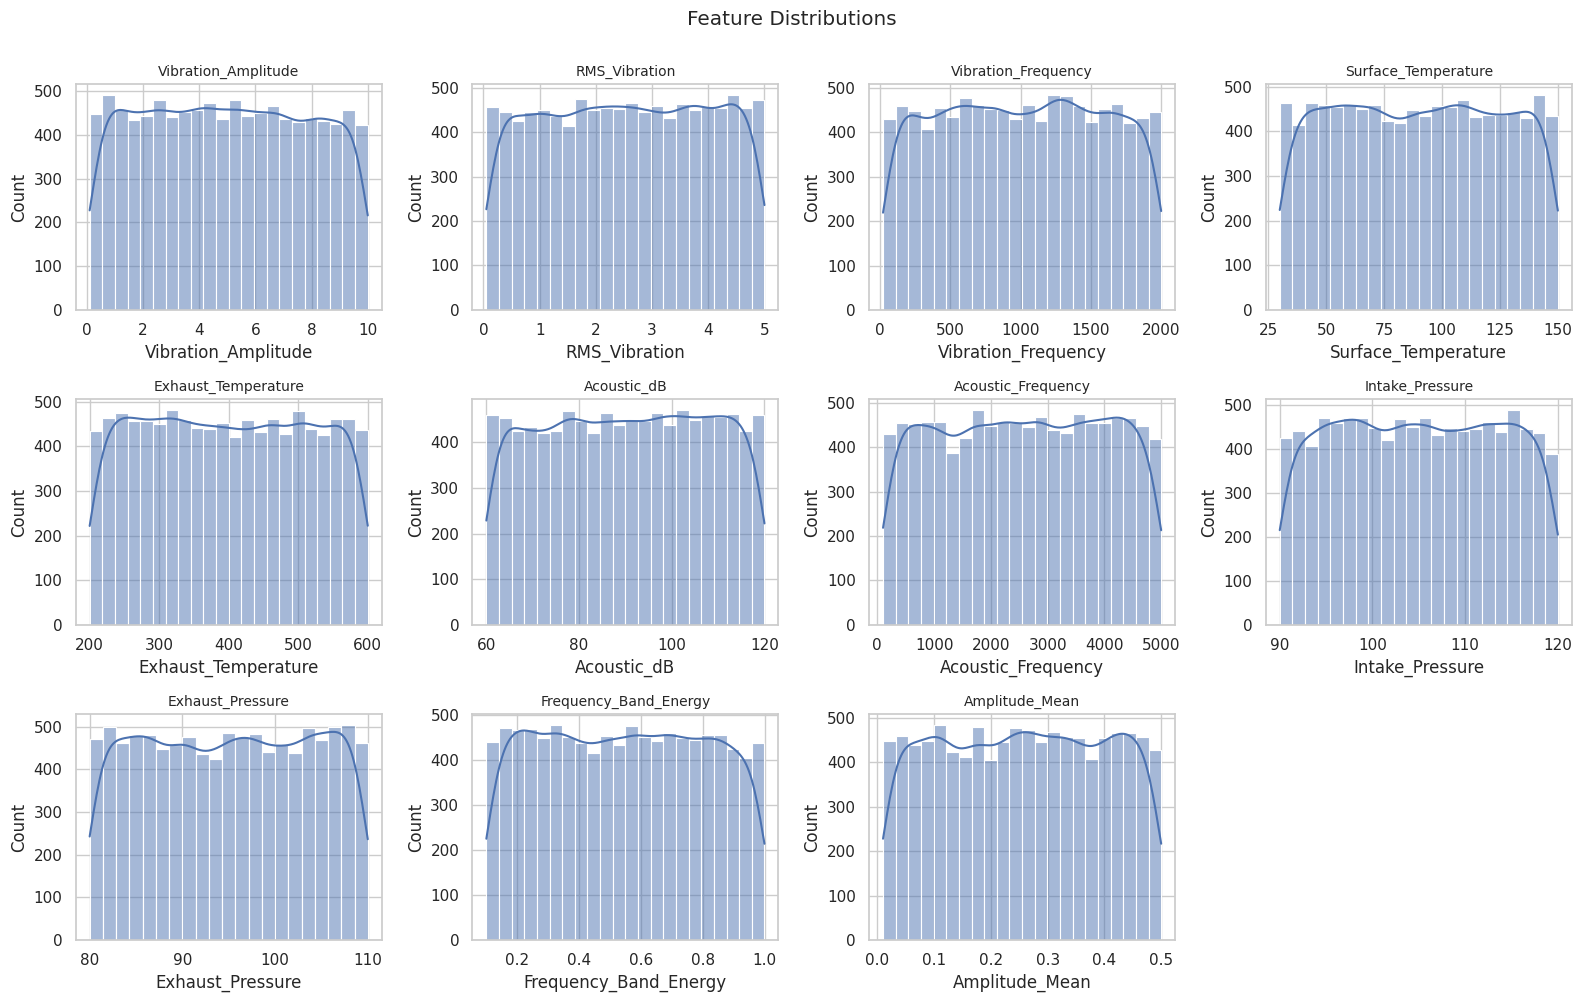

In [15]:
feats = X.columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10)); axes = axes.ravel()
for ax, f in zip(axes, feats):
    sns.histplot(df[f], kde=True, kde_kws={"cut": 0}, ax=ax, color="#4C72B0")
    ax.set_title(f, fontsize=10)
for ax in axes[len(feats):]: ax.axis("off")
plt.suptitle("Feature Distributions", y=1.0); plt.tight_layout(); plt.show()

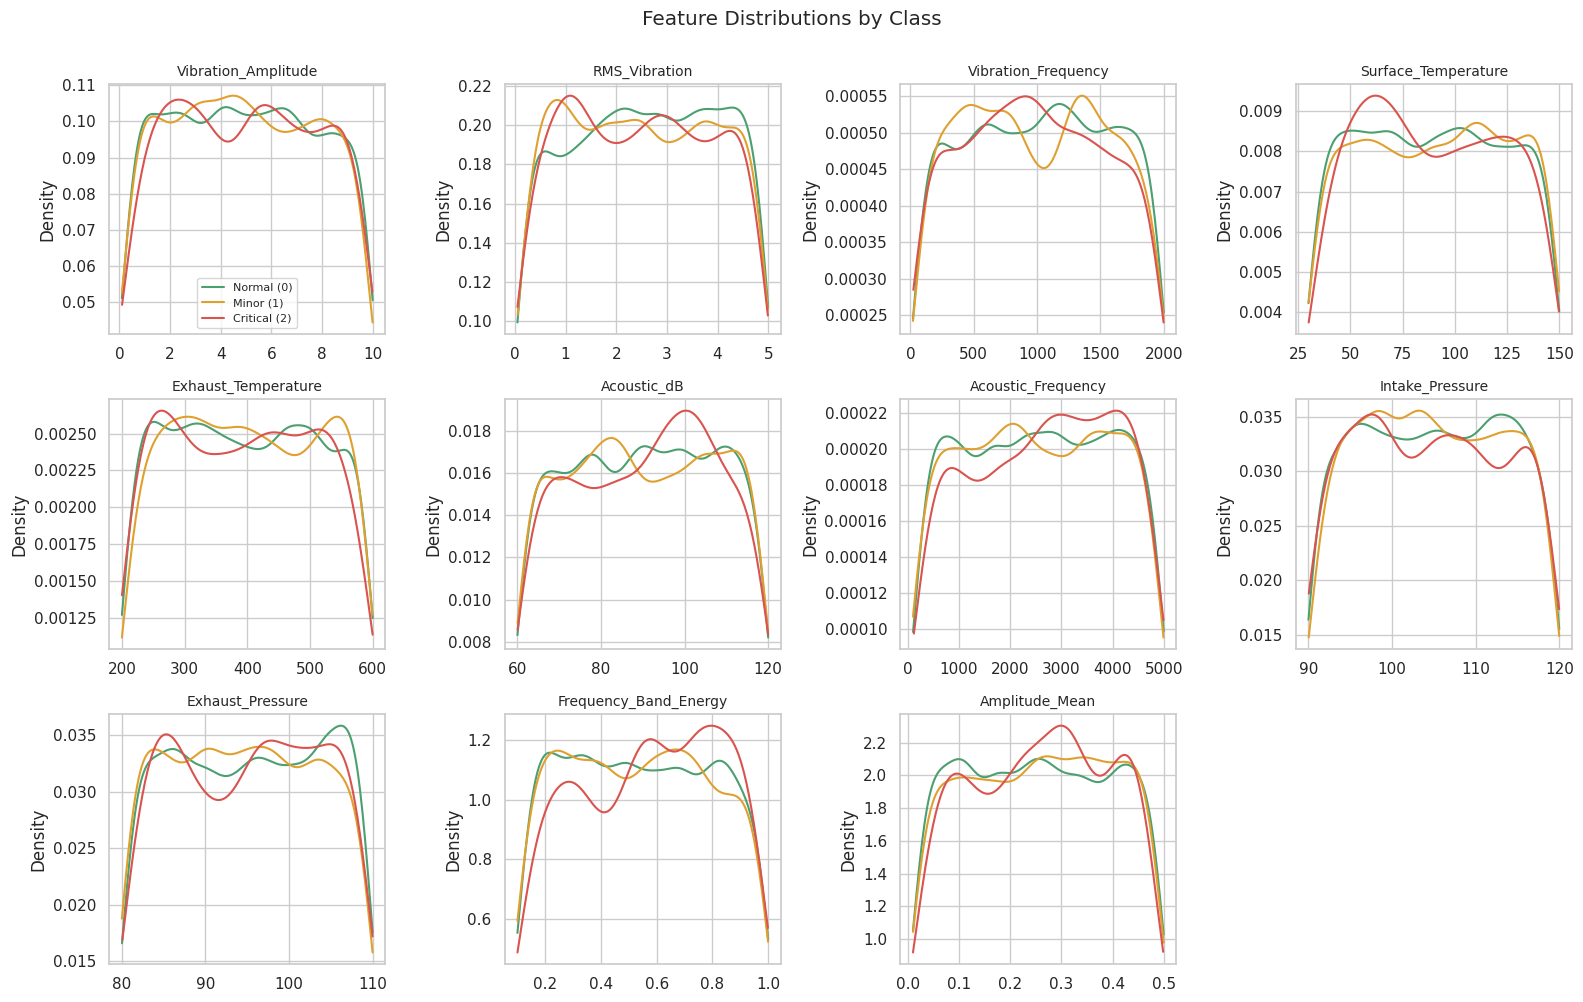

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10)); axes = axes.ravel()
for ax, f in zip(axes, feats):
    for k, col in zip([0, 1, 2], colors):
        sns.kdeplot(df.loc[df.Engine_Condition == k, f].dropna(), ax=ax,
                    color=col, label=labels[k], common_norm=False, cut=0)
    ax.set_title(f, fontsize=10); ax.set_xlabel("")
axes[0].legend(fontsize=8)
for ax in axes[len(feats):]: ax.axis("off")
plt.suptitle("Feature Distributions by Class", y=1.0); plt.tight_layout(); plt.show()

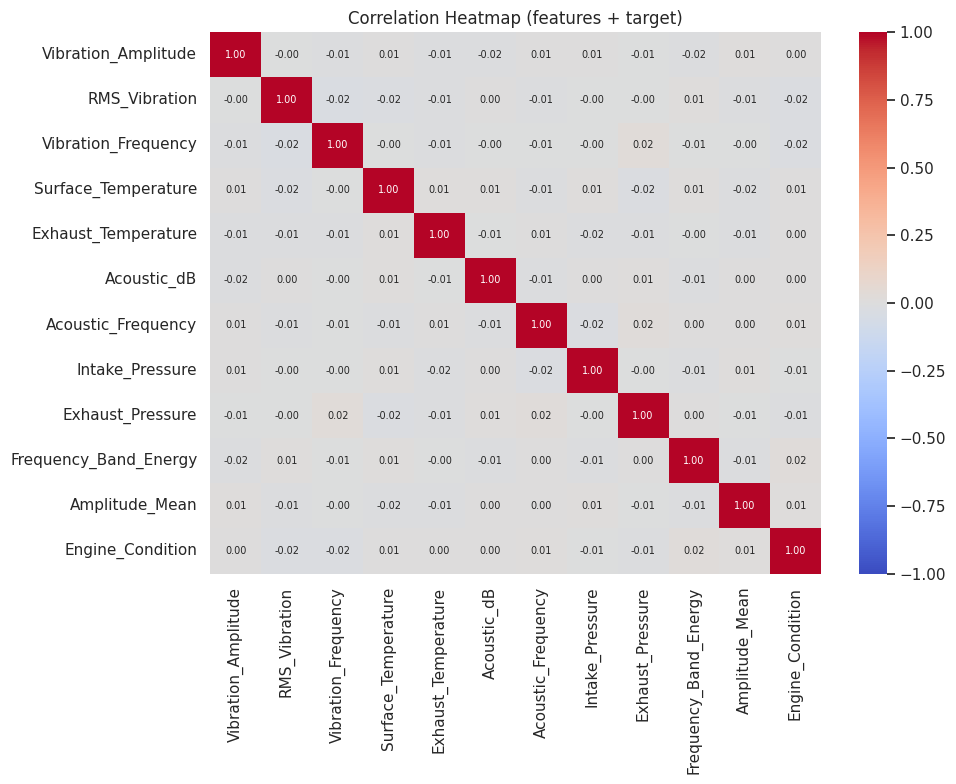

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap (features + target)")
plt.tight_layout(); plt.show()

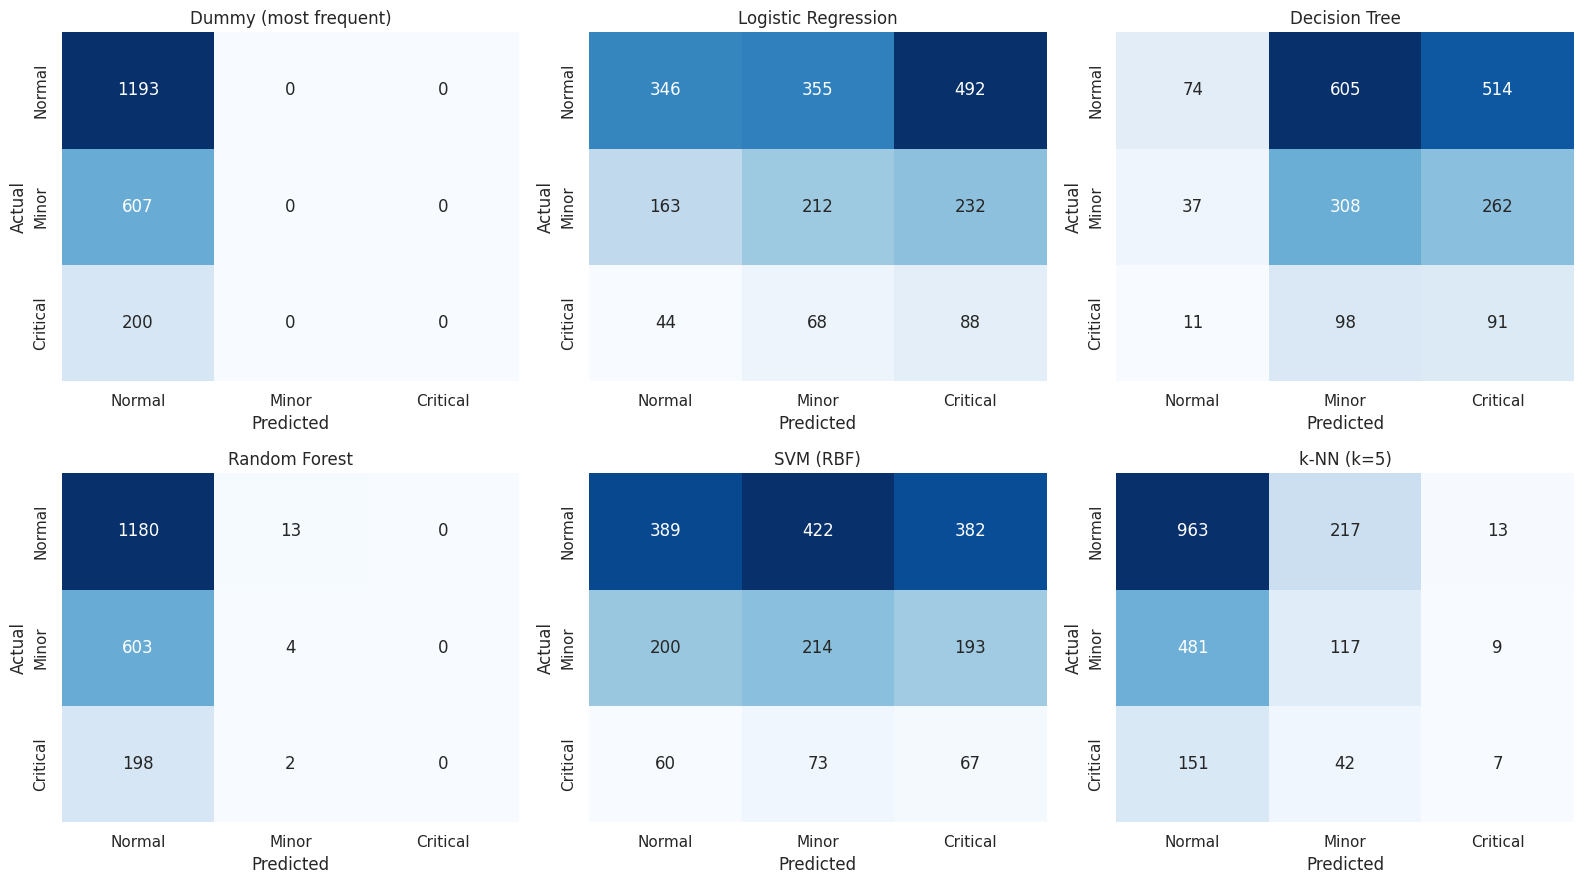

In [18]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()
for ax, name in zip(axes, predictions):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Normal", "Minor", "Critical"],
                yticklabels=["Normal", "Minor", "Critical"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

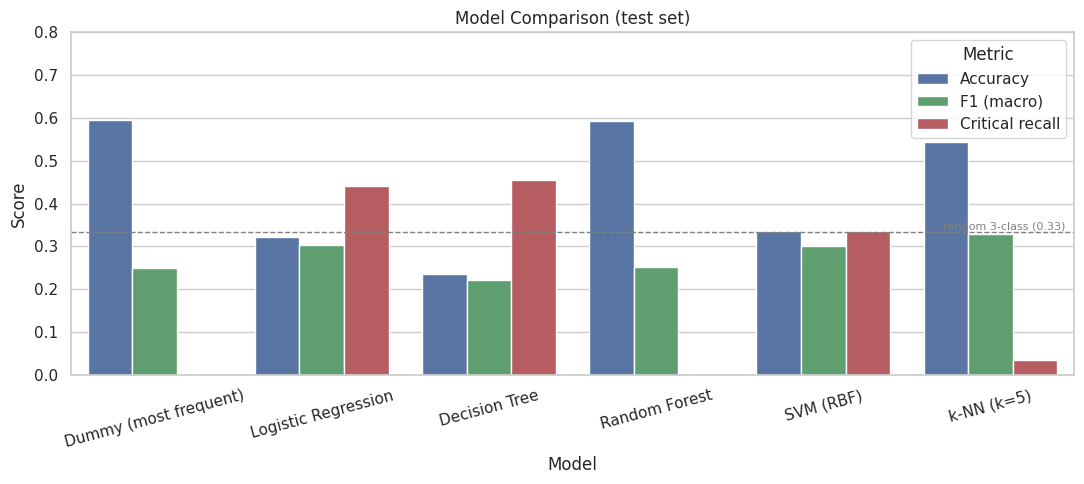

In [19]:
plot_df = (results[["Accuracy", "F1 (macro)", "Critical recall"]]
           .reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score"))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", ax=ax,
            palette=["#4C72B0", "#55A868", "#C44E52"])
ax.axhline(1/3, color="gray", ls="--", lw=1)
ax.text(5.45, 0.34, "random 3-class (0.33)", ha="right", fontsize=8, color="gray")
ax.set_ylim(0, 0.8); ax.set_title("Model Comparison (test set)")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

In [21]:
# Sanity check: does a model do better than it does on RANDOM labels?
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier

scores = []
for seed in range(10):
    y_shuffled = y_train.sample(frac=1, random_state=seed).values
    pipe = make_pipe(KNeighborsClassifier()).fit(X_train, y_shuffled)
    scores.append(f1_score(y_test, pipe.predict(X_test), average="macro"))
print("k-NN macro F1 with shuffled labels:", round(np.mean(scores), 3))

k-NN macro F1 with shuffled labels: 0.31


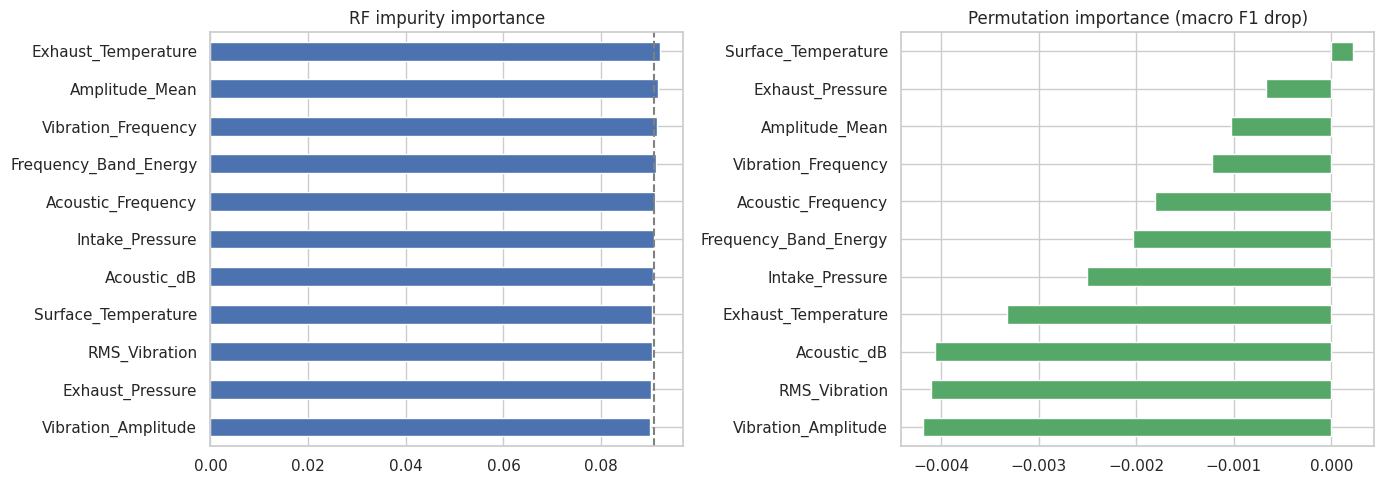

,F,p-value
Frequency_Band_Energy,4.4856,0.0113
Exhaust_Pressure,2.9571,0.0520
RMS_Vibration,2.4684,0.0848
Acoustic_Frequency,1.6823,0.1860
Vibration_Frequency,1.4053,0.2453
Exhaust_Temperature,1.2249,0.2938
Surface_Temperature,1.0933,0.3351
Amplitude_Mean,0.5297,0.5888
Vibration_Amplitude,0.5252,0.5914
Intake_Pressure,0.2997,0.7410


In [22]:
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import f_classif

rf = fitted["Random Forest"]

# (a) Impurity-based
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=X.columns).sort_values()

# (b) Permutation importance on the test set
pi = permutation_importance(rf, X_test, y_test, n_repeats=10,
                            random_state=42, scoring="f1_macro", n_jobs=-1)
pi_s = pd.Series(pi.importances_mean, index=X.columns).sort_values()

# (c) ANOVA F-test (feature vs class)
X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=X.columns)
F, p = f_classif(X_imp, y)
anova = pd.DataFrame({"F": F, "p-value": p}, index=X.columns).sort_values("p-value")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
imp.plot.barh(ax=ax[0], color="#4C72B0"); ax[0].set_title("RF impurity importance")
ax[0].axvline(1/11, color="gray", ls="--");
pi_s.plot.barh(ax=ax[1], color="#55A868"); ax[1].set_title("Permutation importance (macro F1 drop)")
plt.tight_layout(); plt.show()
anova.round(4)

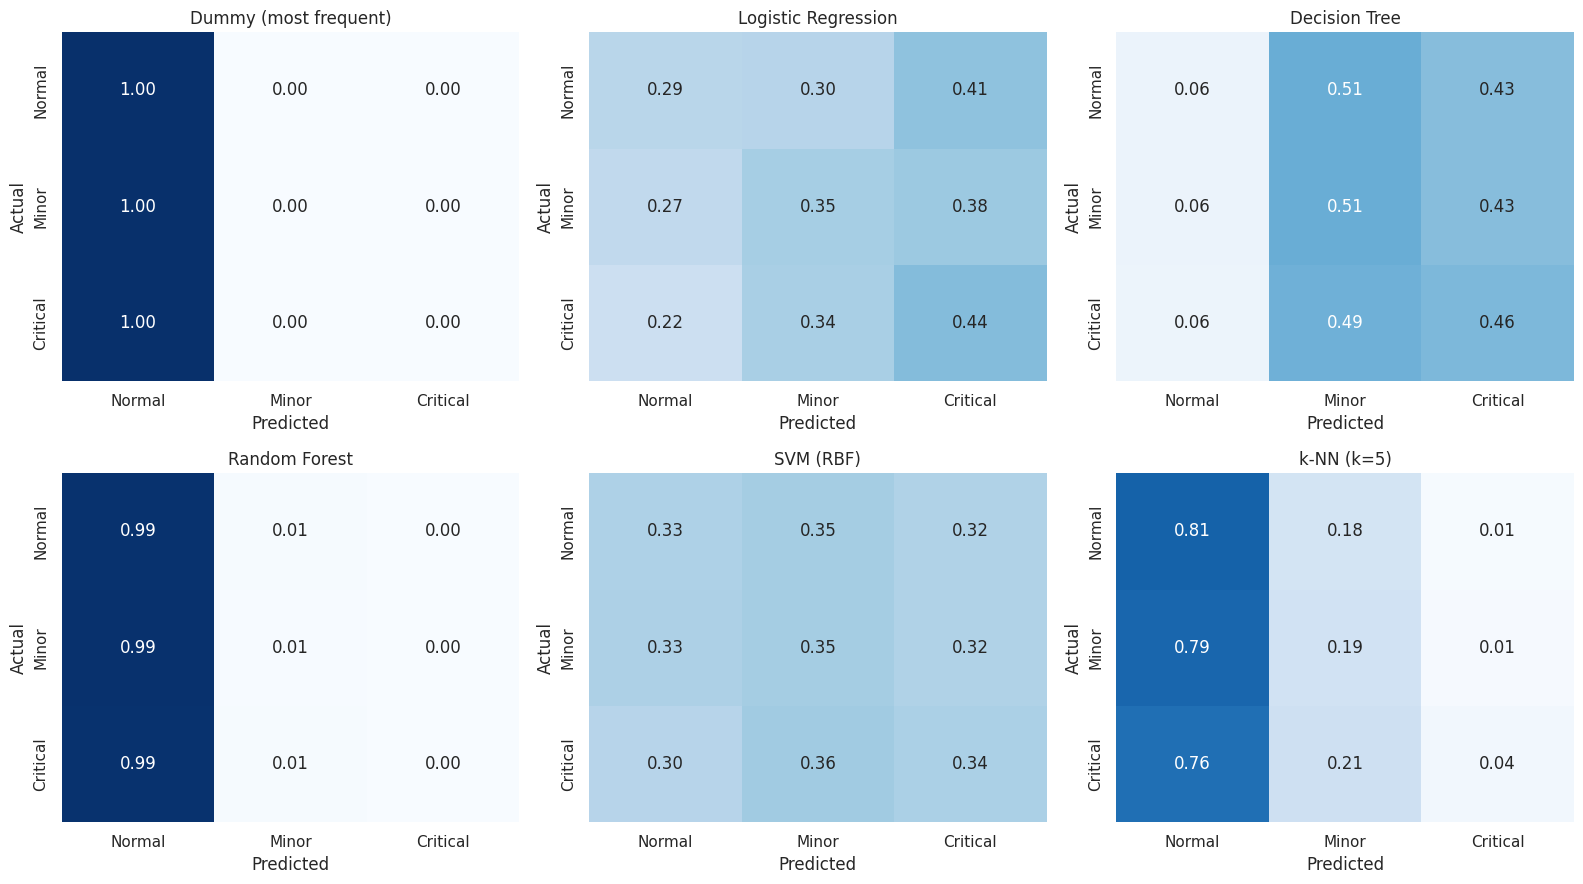

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()
for ax, name in zip(axes, predictions):
    cm = confusion_matrix(y_test, predictions[name])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)           # row-normalized
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax,
                xticklabels=["Normal", "Minor", "Critical"],
                yticklabels=["Normal", "Minor", "Critical"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()